In [81]:
# HDFC Bank Stock Risk Classification using Machine Learning

Objective:
To analyze HDFC Bank stock data using Yahoo Finance,
calculate daily stock risk levels using Z-score analysis,
and build Machine Learning models to predict
the next day's stock risk classification.

In [82]:
# Install Libraries
!pip install yfinance

In [83]:
# Import Libraries
import pandas as pd
import numpy as np

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [84]:
# Downloading the Stock data
df = yf.download(
    "HDFCBANK.NS",
    start="2025-01-01",
    end="2026-05-15"
)

df.head()

C:\Users\scare\AppData\Local\Temp\ipykernel_4668\180871080.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2025-01-01,879.486938,885.036919,868.806297,874.898930,7313806
2025-01-02,884.913635,889.698928,874.677004,876.699651,18558576
2025-01-03,862.935669,885.653615,861.505055,883.556955,24426194
2025-01-06,843.843811,866.882376,841.525176,858.446416,18816348
2025-01-07,845.274414,849.023722,838.663758,846.063733,13527906


In [85]:
# Fixing Multi-Index columns
df.columns = df.columns.get_level_values(0)

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-01,879.486938,885.036919,868.806297,874.898930,7313806
2025-01-02,884.913635,889.698928,874.677004,876.699651,18558576
2025-01-03,862.935669,885.653615,861.505055,883.556955,24426194
2025-01-06,843.843811,866.882376,841.525176,858.446416,18816348
2025-01-07,845.274414,849.023722,838.663758,846.063733,13527906


In [86]:
# Calculate Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

C:\Users\scare\AppData\Local\Temp\ipykernel_4668\3605721154.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Daily_Return'] = df['Close'].pct_change()


In [87]:
# Remove Null Values
df.dropna(inplace=True)

df.head()

Price,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,
2025-01-02,884.913635,889.698928,874.677004,876.699651,18558576,0.006170
2025-01-03,862.935669,885.653615,861.505055,883.556955,24426194,-0.024836
2025-01-06,843.843811,866.882376,841.525176,858.446416,18816348,-0.022124
2025-01-07,845.274414,849.023722,838.663758,846.063733,13527906,0.001695
2025-01-08,835.851868,844.411160,830.449850,842.733820,19738190,-0.011147


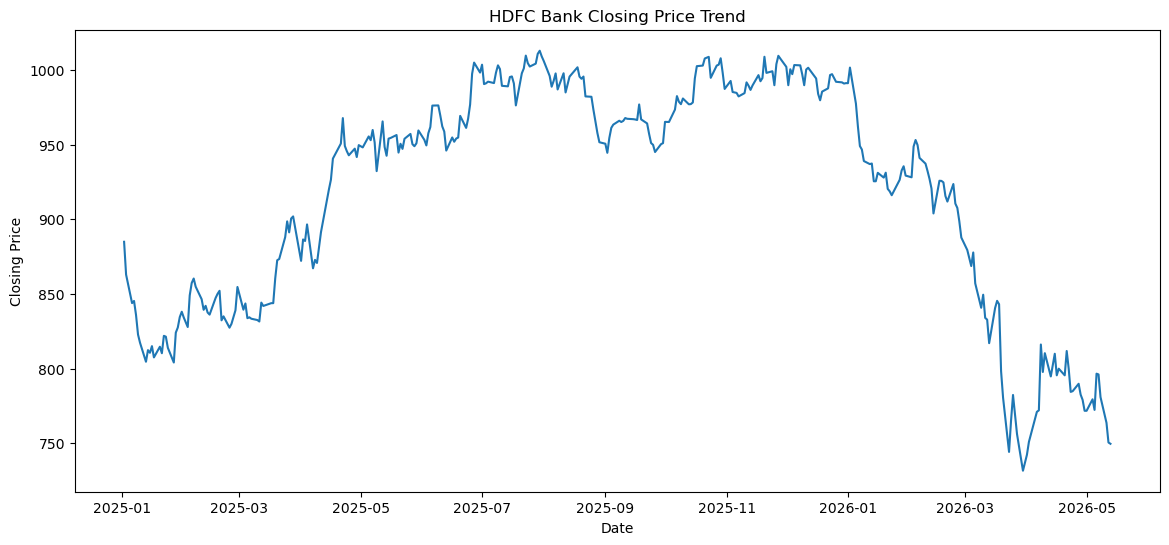

In [88]:
# Stock Price Trend
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title("HDFC Bank Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.show()

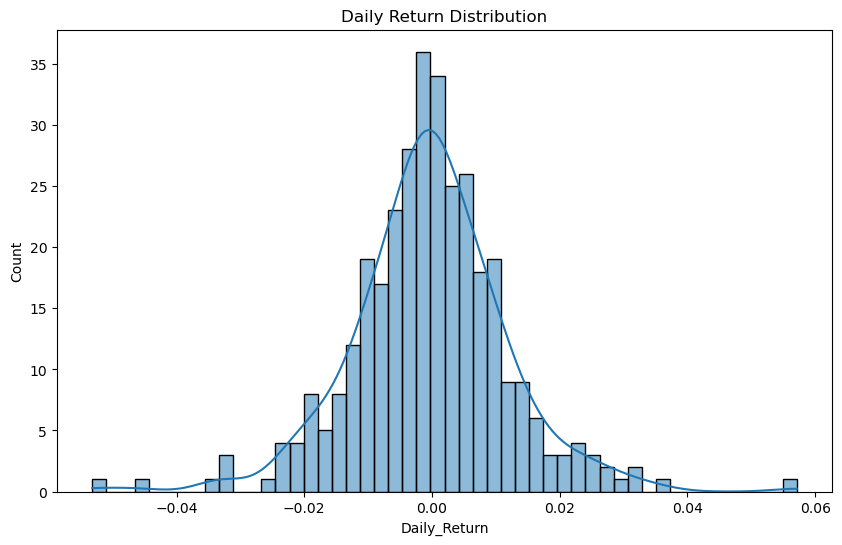

In [89]:
# Visualizing Daily Returns
plt.figure(figsize=(10,6))

sns.histplot(
    df['Daily_Return'],
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

EDA Insights:

- HDFC Bank stock prices showed fluctuations across the selected period.
- Daily returns contain both positive and negative movements.
- Return distribution helps understand stock volatility behavior.
- Volatility analysis is important for financial risk classification.

In [90]:
# Z-score Calculation
df['Z_Score'] = (
    df['Daily_Return'] - df['Daily_Return'].mean()
) / df['Daily_Return'].std()

df.head()

Price,Close,High,Low,Open,Volume,Daily_Return,Z_Score
Date,,,,,,,
2025-01-02,884.913635,889.698928,874.677004,876.699651,18558576,0.006170,0.540253
2025-01-03,862.935669,885.653615,861.505055,883.556955,24426194,-0.024836,-2.009208
2025-01-06,843.843811,866.882376,841.525176,858.446416,18816348,-0.022124,-1.786221
2025-01-07,845.274414,849.023722,838.663758,846.063733,13527906,0.001695,0.172307
2025-01-08,835.851868,844.411160,830.449850,842.733820,19738190,-0.011147,-0.883657


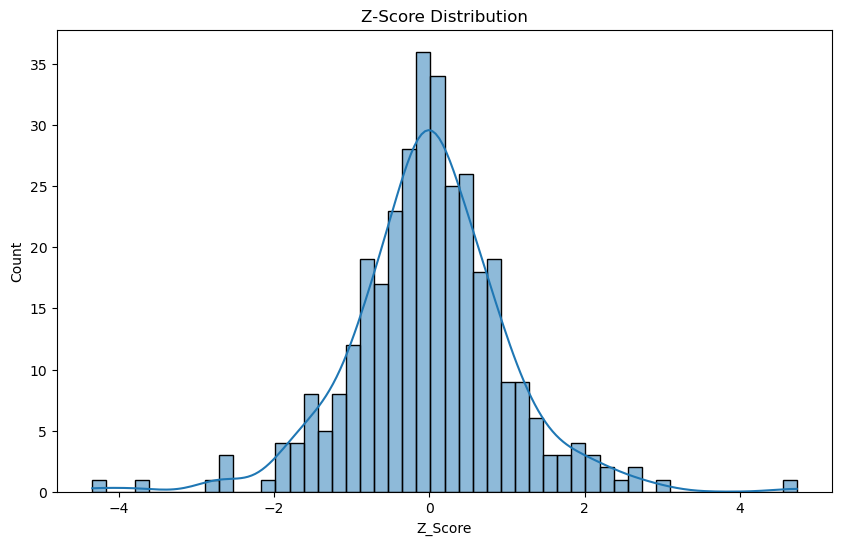

In [91]:
# Visualizing Z-Score
plt.figure(figsize=(10,6))

sns.histplot(
    df['Z_Score'],
    bins=50,
    kde=True
)

plt.title("Z-Score Distribution")

plt.show()

In [92]:
# Creating Risk Classes
conditions = [
    (df['Z_Score'] < -1),
    (df['Z_Score'] >= -1) & (df['Z_Score'] <= 1),
    (df['Z_Score'] > 1)
]

risk_labels = [
    'Low Risk',
    'Medium Risk',
    'High Risk'
]

df['Risk_Class'] = np.select(
    conditions,
    risk_labels,
    default='Medium Risk'
)

df.head()

Price,Close,High,Low,Open,Volume,Daily_Return,Z_Score,Risk_Class
Date,,,,,,,,
2025-01-02,884.913635,889.698928,874.677004,876.699651,18558576,0.006170,0.540253,Medium Risk
2025-01-03,862.935669,885.653615,861.505055,883.556955,24426194,-0.024836,-2.009208,Low Risk
2025-01-06,843.843811,866.882376,841.525176,858.446416,18816348,-0.022124,-1.786221,Low Risk
2025-01-07,845.274414,849.023722,838.663758,846.063733,13527906,0.001695,0.172307,Medium Risk
2025-01-08,835.851868,844.411160,830.449850,842.733820,19738190,-0.011147,-0.883657,Medium Risk


In [93]:
# Risk Class Counts
df['Risk_Class'].value_counts()

Risk_Class
Medium Risk    257
Low Risk        41
High Risk       39
Name: count, dtype: int64

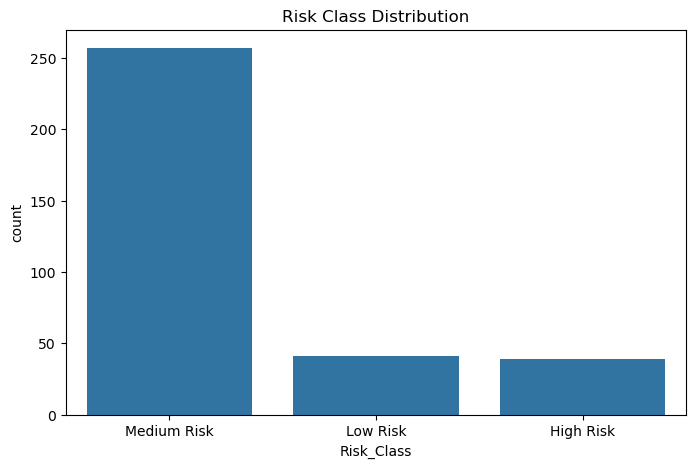

In [94]:
# Visualizing Risk Classes
plt.figure(figsize=(8,5))

sns.countplot(
    x='Risk_Class',
    data=df
)

plt.title("Risk Class Distribution")

plt.show()

Risk Classification Insights:

- Most trading days fall under medium-risk behavior.
- Extreme market movements are less frequent.
- Z-score classification helps simplify stock volatility analysis.
- Risk categories improve interpretability for financial analytics.

In [95]:
# Feature Engineering

# Creating Moving Averages

# 5 Day Moving Average
df['MA_5'] = df['Close'].rolling(window=5).mean()

# 10 Day Moving Average
df['MA_10'] = df['Close'].rolling(window=10).mean()

In [96]:
# Create Volatility Feature
df['Volatility'] = df['Daily_Return'].rolling(window=5).std()

In [97]:
# Removing Null Values again
df.dropna(inplace=True)

df.head()

Price,Close,High,Low,Open,Volume,Daily_Return,Z_Score,Risk_Class,MA_5,MA_10,Volatility
Date,,,,,,,,,,,
2025-01-15,810.568542,820.262461,807.238554,817.203829,14022892,-0.002156,-0.144360,Medium Risk,813.508826,834.036353,0.010560
2025-01-16,815.008545,819.201864,810.469858,815.403174,21212454,0.005478,0.483300,Medium Risk,811.954822,827.045844,0.009987
2025-01-17,807.460571,814.243881,803.390585,810.790560,23112076,-0.009261,-0.728576,Medium Risk,809.981494,821.498334,0.010364
2025-01-20,814.613831,819.399123,802.157207,802.157207,17557618,0.008859,0.761323,Medium Risk,811.994275,818.575336,0.008071
2025-01-21,810.247864,819.448511,805.635225,818.067158,31158144,-0.005360,-0.407769,Medium Risk,811.579871,815.072681,0.007524


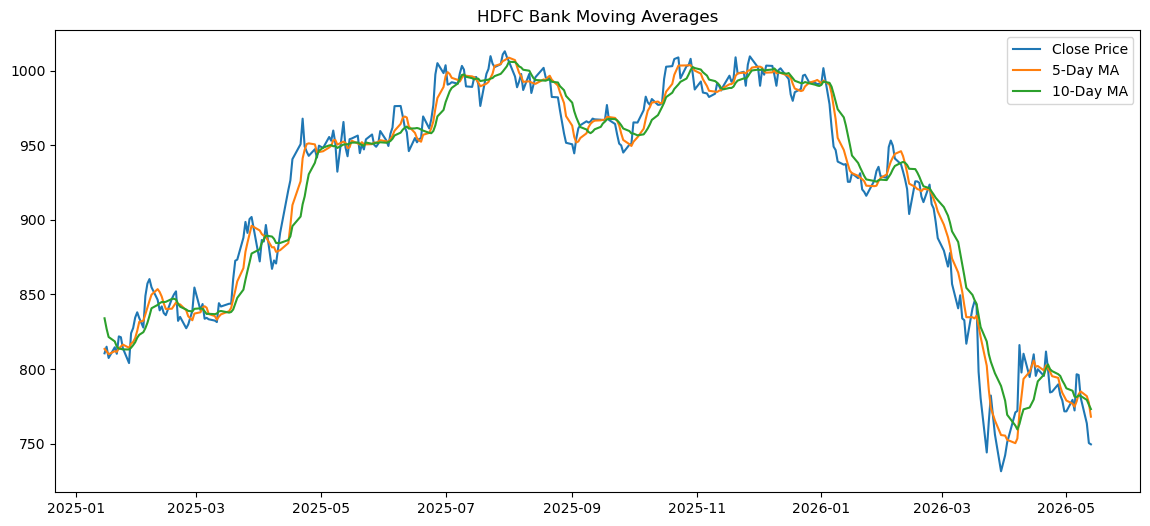

In [98]:
# Visualizing Moving Averages
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['MA_5'], label='5-Day MA')

plt.plot(df['MA_10'], label='10-Day MA')

plt.title("HDFC Bank Moving Averages")

plt.legend()

plt.show()

In [99]:
# Shifting the Target variable to Next Day Target
df['Target'] = df['Risk_Class'].shift(-1)

In [100]:
# Removing Null values from Target Variable
df.dropna(inplace=True)

In [101]:
# Feature Selection

# Define Features
X = df[[
    'Close',
    'Volume',
    'Daily_Return',
    'MA_5',
    'MA_10',
    'Volatility'
]]

# Define target
y = df['Target']

In [102]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 1) KNN Model

In [104]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [105]:
# KNN Prediction
knn_pred = knn.predict(X_test)

In [106]:
# KNN Accuracy
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

knn_accuracy

0.7727272727272727

In [107]:
# KNN Report
print(
    classification_report(
        y_test,
        knn_pred
    )
)

              precision    recall  f1-score   support

   High Risk       0.00      0.00      0.00         7
    Low Risk       0.33      0.12      0.18         8
 Medium Risk       0.81      0.98      0.88        51

    accuracy                           0.77        66
   macro avg       0.38      0.37      0.36        66
weighted avg       0.66      0.77      0.71        66



# 2) Decision Tree

In [108]:
# Train Decision Tree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [109]:
# Decision Tree Prediction
dt_pred = dt.predict(X_test)

In [110]:
# Decision Tree Accuracy
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_accuracy

0.5

In [111]:
# Decision Tree Report
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

   High Risk       0.00      0.00      0.00         7
    Low Risk       0.07      0.12      0.09         8
 Medium Risk       0.80      0.63      0.70        51

    accuracy                           0.50        66
   macro avg       0.29      0.25      0.26        66
weighted avg       0.63      0.50      0.55        66



# 3) SVM Model

In [112]:
# Train SVM
svm = SVC()

svm.fit(X_train, y_train)

SVC()

In [113]:
# SVM Prediction
svm_pred = svm.predict(X_test)

In [114]:
# SVM Accuracy
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_accuracy

0.7727272727272727

In [115]:
# SVM Report
print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

   High Risk       0.00      0.00      0.00         7
    Low Risk       0.00      0.00      0.00         8
 Medium Risk       0.77      1.00      0.87        51

    accuracy                           0.77        66
   macro avg       0.26      0.33      0.29        66
weighted avg       0.60      0.77      0.67        66



C:\Users\scare\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\scare\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\scare\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 4) Random Forests

In [116]:
# Train Random Forests
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [117]:
# Random Forests Prediction
rf_pred = rf.predict(X_test)

In [118]:
# Random Forests Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_accuracy

0.7878787878787878

In [119]:
# Random Forests Report
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

   High Risk       0.00      0.00      0.00         7
    Low Risk       0.33      0.12      0.18         8
 Medium Risk       0.81      1.00      0.89        51

    accuracy                           0.79        66
   macro avg       0.38      0.38      0.36        66
weighted avg       0.67      0.79      0.71        66



C:\Users\scare\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\scare\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\scare\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Models Comparison Table

In [120]:
model_results = pd.DataFrame({
    'Model': [
        'KNN',
        'Decision Tree',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        knn_accuracy,
        dt_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,KNN,0.772727
1,Decision Tree,0.500000
2,SVM,0.772727
3,Random Forest,0.787879


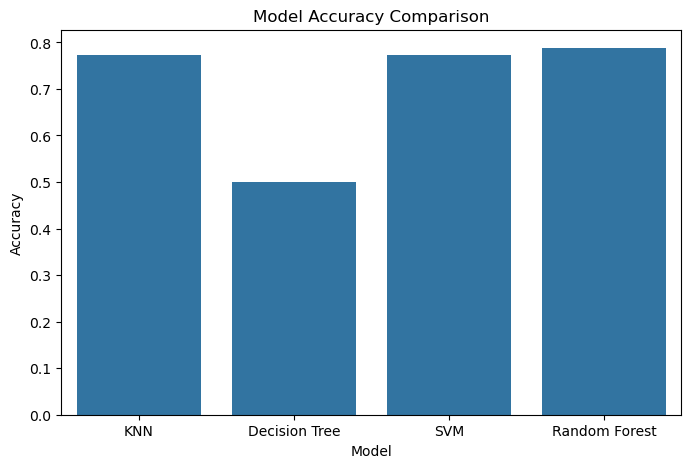

In [121]:
# Visualize the Model Performance
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title("Model Accuracy Comparison")

plt.show()

# Identifying the Best Model

In [122]:
best_model = model_results.sort_values(
    by='Accuracy',
    ascending=False
)

best_model

,Model,Accuracy
3,Random Forest,0.787879
0,KNN,0.772727
2,SVM,0.772727
1,Decision Tree,0.500000


In [123]:
# Random Forests Model gave the highest Accuracy score. So it selected below

In [124]:
# Saving the Best model
joblib.dump(
    rf,
    'hdfc_risk_model.pkl'
)

['hdfc_risk_model.pkl']

In [125]:
# Saving the Scalar so future data can be scled the same way
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

In [126]:
# Loading the selected Model
loaded_model = joblib.load(
    'hdfc_risk_model.pkl'
)

In [127]:
# Loading the scalar
loaded_scaler = joblib.load(
    'scaler.pkl'
)

In [128]:
# Prepare latest data
latest_data = X.iloc[[-1]]

latest_data

Price,Close,Volume,Daily_Return,MA_5,MA_10,Volatility
Date,,,,,,
2026-05-12,750.450012,43937132,-0.017285,777.509998,776.165002,0.022261


In [129]:
# Scale latest data
latest_scaled = loaded_scaler.transform(
    latest_data
)

# Predicting the next day Risk

In [130]:
# Final prediction
prediction = loaded_model.predict(
    latest_scaled
)

prediction

array(['Medium Risk'], dtype=object)

In [131]:
# Displaying the Prediction
print(
    "Predicted Risk Class for 15-May-2026:",
    prediction[0]
)

Predicted Risk Class for 15-May-2026: Medium Risk


In [133]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': list(X.columns),
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Volume,0.199315
5,Volatility,0.178942
2,Daily_Return,0.163134
4,MA_10,0.154834
3,MA_5,0.154020
0,Close,0.149755


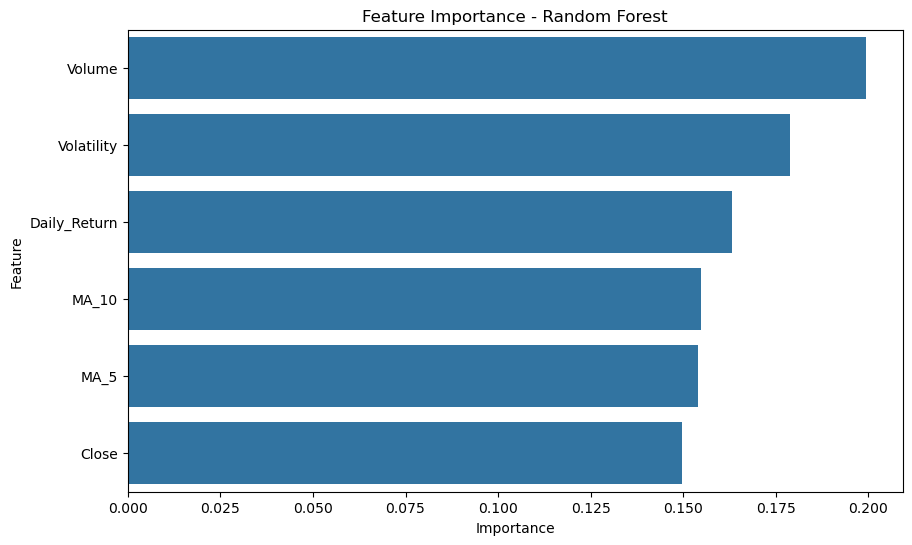

In [134]:
# Visualizing the Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

Business Insights:

- HDFC Bank stock behavior shows varying levels of volatility.
- Moving averages and volatility indicators strongly influence risk classification.
- Random Forest performed best due to its ability to handle non-linear financial patterns.
- Risk classification simplifies financial analytics interpretation.

Business Impact:
- Supports financial risk monitoring
- Helps investors understand volatility behavior
- Assists predictive market analytics
- Demonstrates practical machine learning applications in finance

# Final Conclusion:

A complete stock risk classification system was successfully developed
using HDFC Bank stock data from Yahoo Finance.

The project included:
- Financial data collection
- Feature engineering
- Z-score based risk classification
- Multiple machine learning models
- Model comparison
- Model saving and prediction

Among the evaluated models,
Random Forest delivered the best performance for stock risk prediction.

The project demonstrates how machine learning can support:
- financial analytics
- stock volatility analysis
- predictive risk monitoring
- data-driven investment insights